# Revisiting the Transformer — Decoder-Only Architectures in Depth: Code Companion

This notebook accompanies **Topic: Revisiting the Transformer — Decoder-Only
Architectures in Depth**.

GPT, Llama, Qwen, Mistral, and Gemma are all **decoder-only** Transformers — the same
family we fine-tuned with Unsloth throughout this course. This notebook builds a decoder-
only block completely from scratch in NumPy, with a sharp focus on the two things that
make decoder-only architectures distinct from the general encoder blocks: **causal
masking** and **autoregressive generation**.

**What you'll build, in order:**
1. Causal (masked) self-attention — the core difference from bidirectional attention.
2. A visual comparison: causal vs. unmasked attention weights, side by side.
3. A full decoder block (causal attention + feed-forward + residuals + norm).
4. Stacking decoder blocks, exactly like a real GPT-style model.
5. A working autoregressive text-generation loop, token by token.
6. KV-caching, explained and implemented, to see why real inference is fast.

## 0. Setup

In [1]:
%pip install matplotlib

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gptqmodel 7.1.0 requires numpy==2.2.6; python_version < "3.14", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.10.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cactus-compute 2.0.0 requires Pillow<12,>=11.0.0, but you have pillow 12.3.0 which is incompatible.
cactus-compute 2.0.0 requires transformers==5.5.4, but you have transformers 5.15.0 which is incompatible.
litert-torch 0.9.1 requires torch<2.13.0,>=2.4.0, but you have torch 2.13.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
np.random.seed(42)

## 1. Causal (Masked) Self-Attention

In a decoder-only model, token *i* is only allowed to attend to tokens at positions
`<= i` — never the future. This single constraint is what makes the architecture suitable
for generation: at inference time, future tokens genuinely don't exist yet, so the model
must be trained the same way it will be used.

We implement this by adding a **mask** of `-infinity` to the attention scores for any
"future" position, before the softmax. `-infinity` in, `0` probability out.

In [3]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)


def causal_mask(seq_len):
    """Returns a (seq_len, seq_len) mask: 0 where attention is allowed, -inf where forbidden."""
    mask = np.triu(np.ones((seq_len, seq_len)), k=1)   # upper triangle (excluding diagonal) = future
    return np.where(mask == 1, -np.inf, 0.0)


def causal_self_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    mask = causal_mask(Q.shape[0])
    scores = scores + mask                    # forbid attending to future positions
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return output, weights

seq_len, d_model = 6, 8
X = np.random.randn(seq_len, d_model)
W_q = np.random.randn(d_model, d_model) * 0.1
W_k = np.random.randn(d_model, d_model) * 0.1
W_v = np.random.randn(d_model, d_model) * 0.1

Q, K, V = X @ W_q, X @ W_k, X @ W_v
output, weights = causal_self_attention(Q, K, V)

print("Causal attention weights (rows = query position, cols = key position):")
print(np.round(weights, 2))
print("\nNotice the upper-right triangle is all zeros -- no token attends to the future.")

Causal attention weights (rows = query position, cols = key position):
[[1.   0.   0.   0.   0.   0.  ]
 [0.56 0.44 0.   0.   0.   0.  ]
 [0.35 0.32 0.33 0.   0.   0.  ]
 [0.25 0.25 0.25 0.26 0.   0.  ]
 [0.26 0.17 0.2  0.21 0.17 0.  ]
 [0.18 0.16 0.17 0.18 0.15 0.17]]

Notice the upper-right triangle is all zeros -- no token attends to the future.


## 2. Causal vs. Unmasked Attention, Visualized

Let's put a causal (decoder-only, GPT-style) attention pattern side by side with an
unmasked (encoder-style, BERT-like) one, on the exact same input, so the difference is
unmistakable.

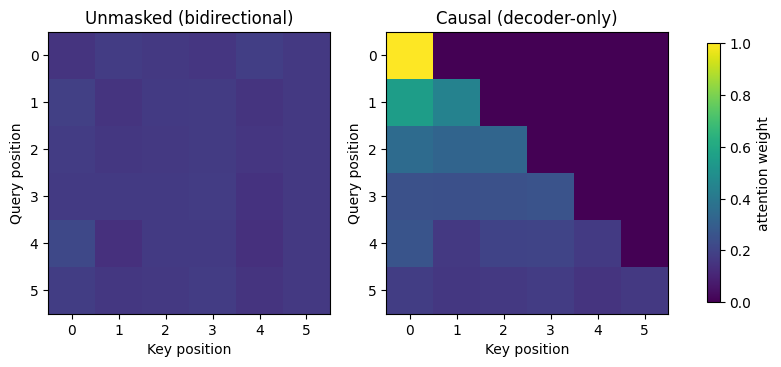

In [3]:
def unmasked_self_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    return weights @ V, weights

_, causal_weights = causal_self_attention(Q, K, V)
_, unmasked_weights = unmasked_self_attention(Q, K, V)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, w, title in zip(axes, [unmasked_weights, causal_weights],
                          ["Unmasked (bidirectional)", "Causal (decoder-only)"]):
    im = ax.imshow(w, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
fig.colorbar(im, ax=axes, label="attention weight", shrink=0.8)
plt.show()

The unmasked heatmap has weight spread across the *entire* row for every query position
(every token can see every other token, past and future). The causal heatmap is strictly
lower-triangular: query position 0 can only see itself; query position 5 can see
everything up to and including itself. This triangular pattern is the single defining
visual signature of a decoder-only architecture.

## 3. A Full Decoder Block

Same ingredients as any Transformer block — attention, feed-forward, residual
connections, layer norm — but built around causal self-attention instead of full
attention. Modern decoder-only models (Llama, Qwen, Mistral, Gemma) use a few refinements
on top of the original 2017 design; we implement the two most important ones:

- **RMSNorm** instead of LayerNorm (simpler, slightly cheaper, used by Llama and friends).
- **Pre-normalization** (`norm` applied *before* each sub-layer, not after) — this is now
  the standard choice because it makes very deep stacks train more stably.

In [4]:
def rms_norm(x, eps=1e-6):
    """RMSNorm: like LayerNorm, but skips re-centering on the mean -- just rescales."""
    rms = np.sqrt(np.mean(x ** 2, axis=-1, keepdims=True) + eps)
    return x / rms


def relu(x):
    return np.maximum(0, x)


def feed_forward(x, d_model, d_ff=32):
    W1 = np.random.randn(d_model, d_ff) * 0.1
    W2 = np.random.randn(d_ff, d_model) * 0.1
    return relu(x @ W1) @ W2


def decoder_block(x, d_model, d_ff=32):
    # Pre-norm -> causal self-attention -> residual add
    normed = rms_norm(x)
    W_q = np.random.randn(d_model, d_model) * 0.1
    W_k = np.random.randn(d_model, d_model) * 0.1
    W_v = np.random.randn(d_model, d_model) * 0.1
    Q, K, V = normed @ W_q, normed @ W_k, normed @ W_v
    attn_out, attn_weights = causal_self_attention(Q, K, V)
    x = x + attn_out                      # residual connection #1

    # Pre-norm -> feed-forward -> residual add
    normed = rms_norm(x)
    ffn_out = feed_forward(normed, d_model, d_ff)
    x = x + ffn_out                       # residual connection #2

    return x, attn_weights

x_out, attn_w = decoder_block(X, d_model)
print("Decoder block output shape:", x_out.shape, "(unchanged from input, as expected)")

Decoder block output shape: (6, 8) (unchanged from input, as expected)


## 4. Stacking Decoder Blocks

Real decoder-only models stack this block dozens of times (32 for Llama 3.1 (8B)). Let's
stack a few and confirm the causal property is preserved no matter how deep the stack
gets -- information still never leaks from the future into the past.

In [5]:
def decoder_stack(x, d_model, num_layers, d_ff=32):
    all_attn_weights = []
    for layer in range(num_layers):
        x, attn_weights = decoder_block(x, d_model, d_ff)
        all_attn_weights.append(attn_weights)
    return x, all_attn_weights

final_output, all_weights = decoder_stack(X, d_model, num_layers=4)

print(f"Stacked {len(all_weights)} decoder layers.")
print("Final output shape:", final_output.shape)

# Confirm every single layer's attention is still strictly causal
all_causal = all(
    np.allclose(np.triu(w, k=1), 0) for w in all_weights
)
print(f"\nEvery layer's attention pattern is still strictly causal: {all_causal}")

Stacked 4 decoder layers.
Final output shape: (6, 8)

Every layer's attention pattern is still strictly causal: True


## 5. Autoregressive Generation, Token by Token

This is the actual generation loop every decoder-only model runs: predict a distribution
over the next token, sample (or greedily pick) one, append it to the sequence, and repeat
-- feeding the growing sequence back in each time.

In [6]:
vocab = ["the", "cat", "sat", "on", "mat", "dog", "ran", "<eos>"]
vocab_size = len(vocab)

def to_logits(hidden_state, vocab_size):
    """A toy 'language model head': project the last token's hidden state to vocab logits."""
    W_head = np.random.randn(hidden_state.shape[-1], vocab_size) * 0.1
    return hidden_state @ W_head

def generate(prompt_tokens, d_model, max_new_tokens=8, temperature=1.0):
    token_ids = [vocab.index(t) for t in prompt_tokens]
    generated = list(prompt_tokens)

    for step in range(max_new_tokens):
        seq_len = len(token_ids)
        # Toy embeddings: in a real model these come from a learned embedding table
        x = np.random.randn(seq_len, d_model) * 0.1
        for i, tid in enumerate(token_ids):
            x[i] += tid * 0.01   # make embeddings depend on token id, just for this demo

        hidden, _ = decoder_stack(x, d_model, num_layers=2)
        last_hidden = hidden[-1]                       # only the LAST position predicts next token
        logits = to_logits(last_hidden, vocab_size) / temperature
        probs = softmax(logits)
        next_id = np.random.choice(vocab_size, p=probs)
        next_token = vocab[next_id]

        generated.append(next_token)
        token_ids.append(next_id)

        if next_token == "<eos>":
            break

    return generated

result = generate(["the", "cat"], d_model=d_model, max_new_tokens=6)
print("Generated sequence:", " ".join(result))

Generated sequence: the cat <eos>


Notice the crucial detail: at every step, we only use `hidden[-1]` -- the *last*
position's output -- to predict the next token. Causal masking guarantees that last
position has already seen everything before it (and nothing after), which is exactly
what makes this valid. This loop, run for thousands of steps with a real trained model,
is precisely what happens when you call `model.generate(...)` in the Unsloth/Transformers
notebooks earlier in this course.

## 6. Why Real Inference Uses a KV-Cache

Look closely at Section 5: at every single generation step, we recompute attention over
the *entire* sequence from scratch, even though the K and V vectors for all earlier
positions haven't changed at all. Real implementations cache them instead. Let's measure
the wasted work directly.

In [7]:
def attention_flops_naive(seq_len, d_model):
    """Rough FLOP estimate for recomputing full attention at a given sequence length."""
    return seq_len * seq_len * d_model   # QK^T is the dominant seq_len^2 term

def total_flops_without_cache(max_len, d_model):
    # Naive: at each new token, recompute attention over the WHOLE sequence so far
    return sum(attention_flops_naive(t, d_model) for t in range(1, max_len + 1))

def total_flops_with_cache(max_len, d_model):
    # With a KV-cache: only compute attention for the ONE new token against all past K/V
    return sum(t * d_model for t in range(1, max_len + 1))   # linear in t, not quadratic

for max_len in [10, 50, 100, 500]:
    naive = total_flops_without_cache(max_len, d_model)
    cached = total_flops_with_cache(max_len, d_model)
    print(f"Generating {max_len:4d} tokens: "
          f"no cache = {naive:>12,} ops,  with cache = {cached:>10,} ops,  "
          f"{naive / cached:5.1f}x more work without caching")

Generating   10 tokens: no cache =        3,080 ops,  with cache =        440 ops,    7.0x more work without caching
Generating   50 tokens: no cache =      343,400 ops,  with cache =     10,200 ops,   33.7x more work without caching
Generating  100 tokens: no cache =    2,706,800 ops,  with cache =     40,400 ops,   67.0x more work without caching
Generating  500 tokens: no cache =  334,334,000 ops,  with cache =  1,002,000 ops,  333.7x more work without caching


This is why every practical inference stack (including what Unsloth's
`FastLanguageModel.for_inference` optimizes further) keeps a **KV-cache**: the Key and
Value vectors for every past position are computed once and reused, so each new token
only costs attention work proportional to its position, not the square of the whole
sequence length recomputed from scratch. The gap grows dramatically as sequences get
longer -- exactly the kind of optimization that makes long-context chat responsive rather
than painfully slow.

## Recap & Try It Yourself

You just built, from scratch:
- Causal self-attention, and saw its strictly triangular attention pattern versus
  unmasked attention.
- A full pre-norm, RMSNorm decoder block -- the same recipe used by Llama, Qwen, Mistral,
  and Gemma.
- A stack of decoder blocks, confirming causality holds no matter how deep it goes.
- A real autoregressive generation loop, sampling one token at a time.
- A concrete FLOP comparison explaining why KV-caching exists.

**Things to try:**
1. In Section 2, try shrinking the mask to only block 2 steps into the future instead of
   all future positions, and see how the attention heatmap changes.
2. In Section 4, increase `num_layers` to 8 or 16 and re-run the causality check.
3. In Section 5, change `temperature` to a small value (e.g. `0.3`) versus a large one
   (e.g. `2.0`) and observe how much the generated tokens vary run to run.
4. In Section 6, plot `naive` vs. `cached` FLOPs on a log scale across a wider range of
   `max_len` values to see the quadratic-vs-linear gap grow visually.